In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import numpy as np
# from scipy.spatial.transform import Rotation
# from scipy.optimize import bisect as scipy_bisect
import math

# import bisect
# import uuid

from enum import Enum
# import requests
from pathlib import Path
import os
import h3

import plotly.express as px

from shapely.geometry import Polygon
from shapely.plotting import patch_from_polygon

from fame import *

# import random

from fame_geometry import InstrumentType

In [2]:
R_earth_km = 6371


In [3]:
# Gemini-generated

# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [4]:
tle_file_name_json = "all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [5]:
tle_file_name_txt = "all_tles_20260130.txt"


In [6]:
# planet_satellites = []
# 14-19 decayed

instrument_types = [InstrumentType.RGB, InstrumentType.SAR, InstrumentType.HYPERSPECTRAL]

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
]
pelican_satellites = [
    Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),

]
tanager_satellites = [
    Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL]),
]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB])]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB])]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


In [7]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [8]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {InstrumentType.RGB: _fov}

In [9]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name:
        return "blue"
    # Black
    if "UMBRA" in constellation_name:
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name:
        return "darkorange"
    # 
    if "LOFT" in constellation_name:
        return "forestgreen"
    #
    if "Ubotica" in constellation_name:
        return "lime"
    #
    if "Mission Control" in constellation_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}

constcolor = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [10]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

ground_stations = [
    Location(
        3.8,
        52,
        0,
        "Rotterdam-ish",
    ),
]

# ground_station_opportunities = [
#     observation_request(
#         lon_deg=gs.lon_deg,
#         lat_deg=gs.lat_deg,
#         alt_km=gs.alt_km,
#         min_time=dt.datetime.now(dt.timezone.utc),
#         max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)
#     )
#     for gs in ground_stations
# ]

In [11]:
# LOFT YAM-6 at Feb 14, 1:39

_time = dt.datetime(2026,2,14,1,39,0)
satellite = loft_satellites[0]

ground_footprint_llas = spacecraft_fov(_time, satellite, InstrumentType.RGB, Rotterdam)
print(ground_footprint_llas)

ground_footprint_poly = Polygon([(_lla[0], _lla[1]) for _lla in ground_footprint_llas])

[(np.float64(3.9797718880162023), np.float64(52.022865493716736), 0), (np.float64(3.974591074075188), np.float64(51.94903436745193), 0), (np.float64(3.922052507834008), np.float64(51.887884132548095), 0), (np.float64(3.8359514063969113), np.float64(51.85661710594336), 0), (np.float64(3.739985136643767), np.float64(51.864226337696465), 0), (np.float64(3.6607683705537903), np.float64(51.908447865602184), 0), (np.float64(3.6197796473574746), np.float64(51.97660272416136), 0), (np.float64(3.6273628850683752), np.float64(52.04984660577638), 0), (np.float64(3.6806155359577266), np.float64(52.10879075062826), 0), (np.float64(3.7650278398282877), np.float64(52.138438643236135), 0), (np.float64(3.858591235900942), np.float64(52.131417000406586), 0), (np.float64(3.93709437584034), np.float64(52.08940185106208), 0)]


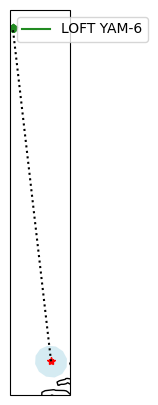

In [12]:
figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

# fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))


# ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
# ax.coastlines()

# request location
# ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
# ground_station = ground_station_dict[gs]
axglobal.plot(float(Rotterdam.lon_deg), float(Rotterdam.lat_deg), '*r', transform=ccrs.PlateCarree(), )

# Where is the satellite?

# _dt = dt.timedelta(seconds=stride_s)
time_steps_for_plotting = [_time,]

_orbit = satellite.orbit
_llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
# ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name, color=satcolor[satellite.name])

axglobal.plot(_llas[0][0],_llas[0][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])
axglobal.plot(_llas[-1][0],_llas[-1][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])

# Where is the satellite looking?
_highest_lla = _llas[0]
axglobal.plot(
    [float(Rotterdam.lon_deg), _highest_lla[0]],
    [float(Rotterdam.lat_deg), _highest_lla[1]],
    ':k',
    transform=ccrs.Geodetic()
)

# ax.plot(
#     [float(orequest.lon_deg), _highest_lla[0]],
#     [float(orequest.lat_deg), _highest_lla[1]],
#     ':k',
#     transform=ccrs.Geodetic()
# )

# request_counter += 1
fpx, fpy = ground_footprint_poly.exterior.xy
# for _ix in range(len(fpx)):
    # print("Printing {}".format(_ix))
# axglobal.plot(fpx, fpy, linewidth=3, solid_capstyle='round', label='Footprint', transform=ccrs.Geodetic())

axglobal.add_patch(patch_from_polygon(ground_footprint_poly, fc='lightblue', ec='none', alpha=0.5, transform=ccrs.Geodetic()))

_plot_offset_deg = 20
axes_extents = (float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Rotterdam.lat_deg)-_plot_offset_deg, float(Rotterdam.lat_deg)+_plot_offset_deg)
# axglobal.set_extent(axes_extents, crs=ccrs.PlateCarree())


axglobal.legend()

In [13]:
ground_footprint_poly.exterior.xy

(array('d', [3.9797718880162023, 3.974591074075188, 3.922052507834008, 3.8359514063969113, 3.739985136643767, 3.6607683705537903, 3.6197796473574746, 3.6273628850683752, 3.6806155359577266, 3.7650278398282877, 3.858591235900942, 3.93709437584034, 3.9797718880162023]),
 array('d', [52.022865493716736, 51.94903436745193, 51.887884132548095, 51.85661710594336, 51.864226337696465, 51.908447865602184, 51.97660272416136, 52.04984660577638, 52.10879075062826, 52.138438643236135, 52.131417000406586, 52.08940185106208, 52.022865493716736]))

In [14]:
print(fpx)
print(fpy)
print(ground_footprint_llas)

array('d', [3.9797718880162023, 3.974591074075188, 3.922052507834008, 3.8359514063969113, 3.739985136643767, 3.6607683705537903, 3.6197796473574746, 3.6273628850683752, 3.6806155359577266, 3.7650278398282877, 3.858591235900942, 3.93709437584034, 3.9797718880162023])
array('d', [52.022865493716736, 51.94903436745193, 51.887884132548095, 51.85661710594336, 51.864226337696465, 51.908447865602184, 51.97660272416136, 52.04984660577638, 52.10879075062826, 52.138438643236135, 52.131417000406586, 52.08940185106208, 52.022865493716736])
[(np.float64(3.9797718880162023), np.float64(52.022865493716736), 0), (np.float64(3.974591074075188), np.float64(51.94903436745193), 0), (np.float64(3.922052507834008), np.float64(51.887884132548095), 0), (np.float64(3.8359514063969113), np.float64(51.85661710594336), 0), (np.float64(3.739985136643767), np.float64(51.864226337696465), 0), (np.float64(3.6607683705537903), np.float64(51.908447865602184), 0), (np.float64(3.6197796473574746), np.float64(51.976602724

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  return utc_time.astype("datetime64[ns]")
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit

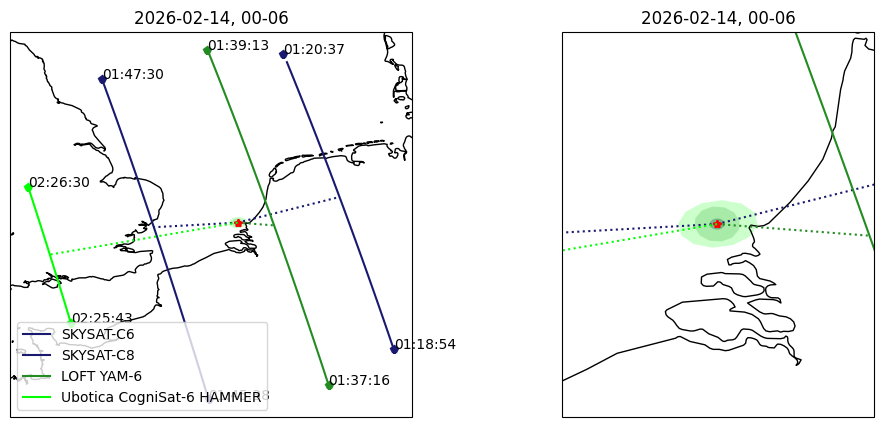

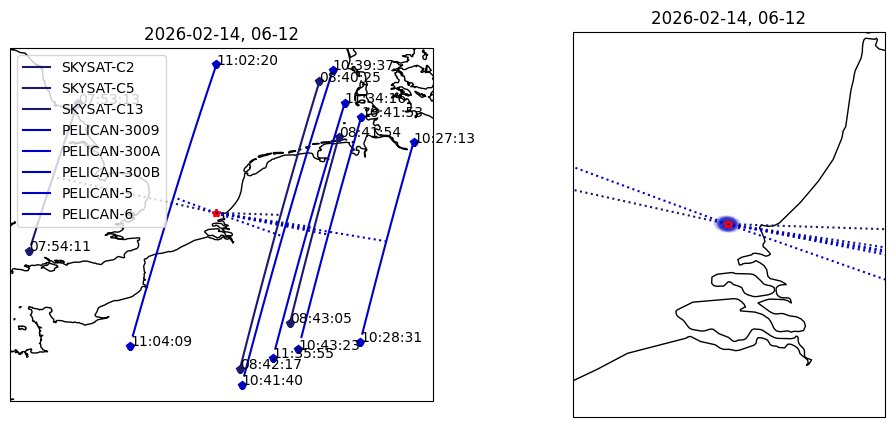

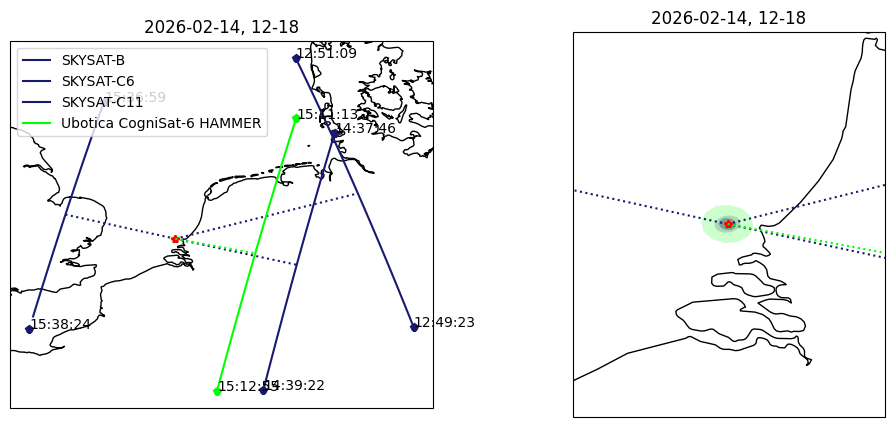

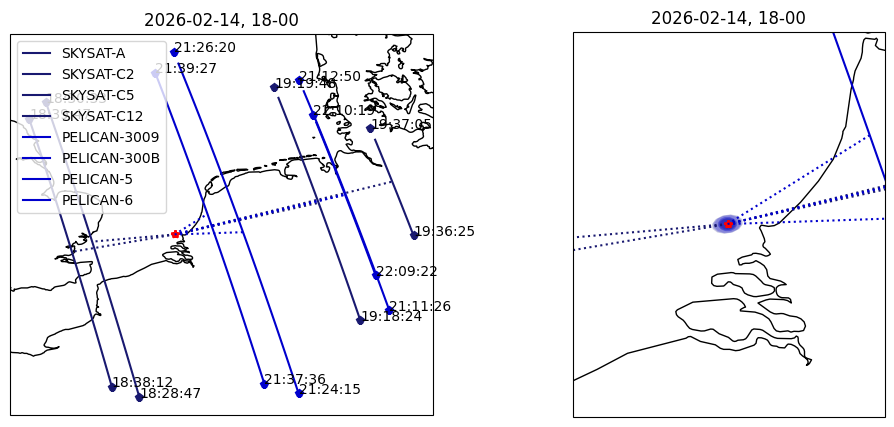

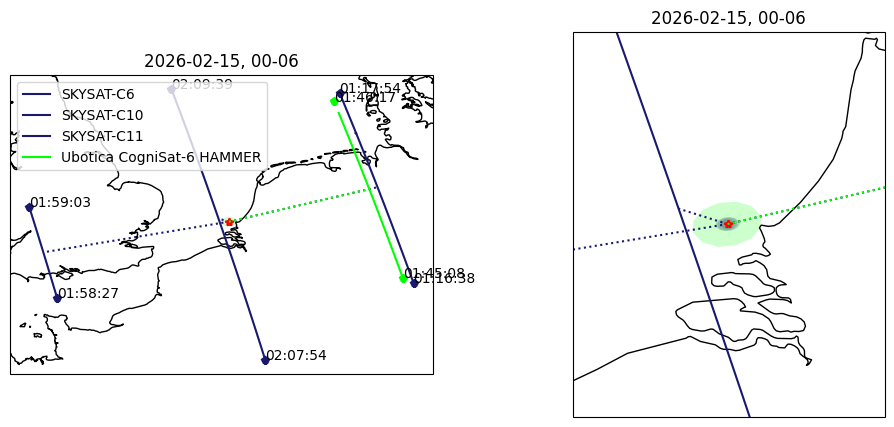

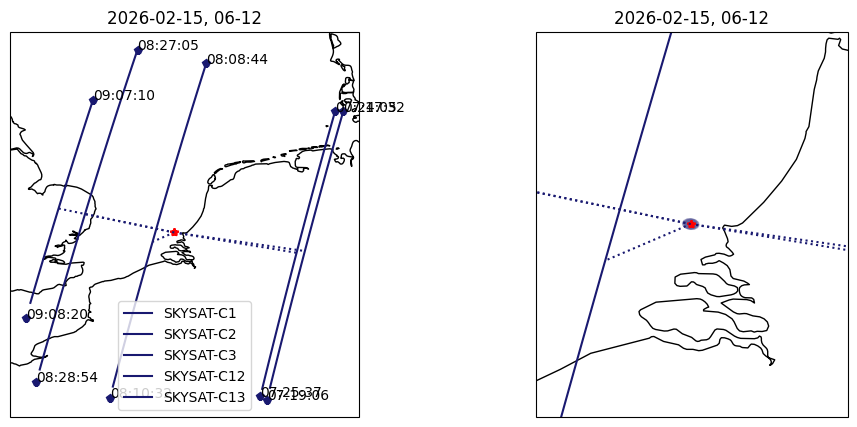

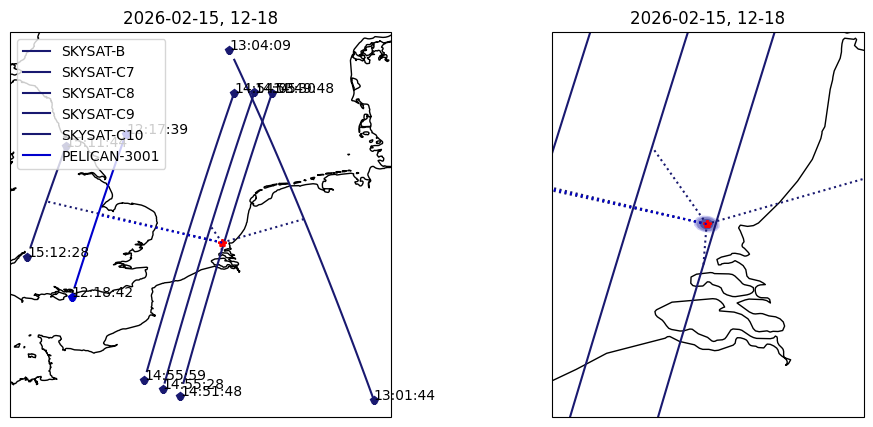

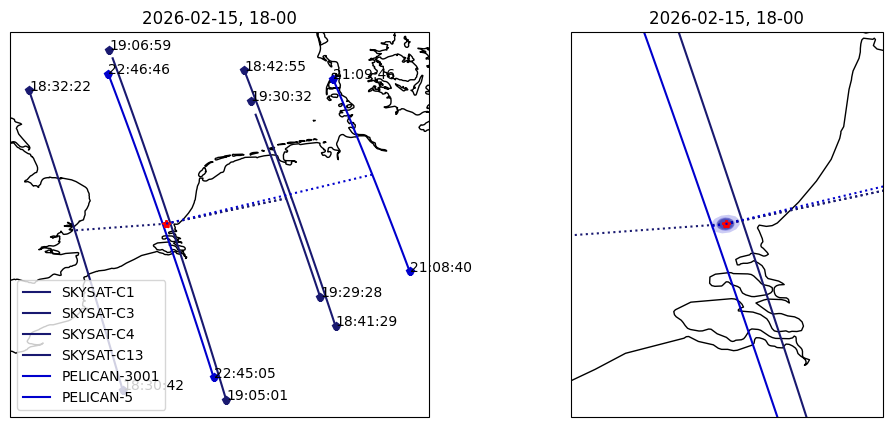

In [15]:
duration_h = 6

_plot_offset_deg = 1

for start_day in range(14,16):
    for start_hour in range(0,24,duration_h):
        min_time = dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0, tzinfo=dt.timezone.utc)
        duration = dt.timedelta(seconds=3600*duration_h)
        comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
            ground_stations=ground_stations,
            satellites=all_satellites,
            min_time=min_time,
            max_time=min_time+duration,
            passes_error_s=60,
            passes_horizon_deg=45
        )

        stride_s = 5
        plot_range_s = 10800

        # comm_opportunities_by_sat

        figglobal = plt.figure(figsize=(12,5))
        axglobal = figglobal.add_subplot(1,2,1, projection=ccrs.Robinson())
        # axglobal.set_global()
        axglobal.coastlines()

        # figlocal = plt.figure(figsize=(10,5))
        axlocal = figglobal.add_subplot(1,2,2, projection=ccrs.Robinson())
        # axglobal.set_global()
        axlocal.coastlines()

        # fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

        ground_station_dict = {gs.name: gs for gs in ground_stations}

        for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
            for (ground_station, satpass) in sat_passes_with_gs:
                # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
                # ax.coastlines()
            
                # request location
                # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
                # ground_station = ground_station_dict[gs]
                axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
            
                axlocal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )

                # Where is the satellite?
            
                _dt = dt.timedelta(seconds=stride_s)
                time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]
            
                _orbit = satellite.orbit
                _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
                # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
                axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name, color=satcolor[satellite.name])
                axlocal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name, color=satcolor[satellite.name])


                _rise_lla = _orbit.get_lonlatalt(satpass.rise.time)
                _fall_lla = _orbit.get_lonlatalt(satpass.fall.time)
                axglobal.plot(_rise_lla[0],_rise_lla[1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])
                axglobal.plot(_fall_lla[0],_fall_lla[1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])

                axlocal.plot(_rise_lla[0],_rise_lla[1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])
                axlocal.plot(_fall_lla[0],_fall_lla[1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])

                axglobal.text(_rise_lla[0],_rise_lla[1], "{}".format(satpass.rise.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())
                axglobal.text(_fall_lla[0],_fall_lla[1], "{}".format(satpass.fall.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())

                # axlocal.text(_rise_lla[0],_rise_lla[1], "{}".format(satpass.rise.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())
                # axlocal.text(_fall_lla[0],_fall_lla[1], "{}".format(satpass.fall.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())

                # Where is the satellite looking?
                _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
                axglobal.plot(
                    [float(ground_station.lon_deg), _highest_lla[0]],
                    [float(ground_station.lat_deg), _highest_lla[1]],
                    ':',
                    color=satcolor[satellite.name],
                    transform=ccrs.Geodetic()
                )

                axlocal.plot(
                    [float(ground_station.lon_deg), _highest_lla[0]],
                    [float(ground_station.lat_deg), _highest_lla[1]],
                    ':',
                    color=satcolor[satellite.name],
                    transform=ccrs.Geodetic()
                )
                ground_footprint_llas = spacecraft_fov(satpass.highest.time, satellite, satellite.instruments[0], ground_station)
                # print(ground_footprint_llas)

                ground_footprint_poly = Polygon([(_lla[0], _lla[1]) for _lla in ground_footprint_llas])
                
                axglobal.add_patch(patch_from_polygon(ground_footprint_poly, fc=satcolor[satellite.name], ec='none', alpha=0.2, transform=ccrs.Geodetic()))
                axlocal.add_patch(patch_from_polygon(ground_footprint_poly, fc=satcolor[satellite.name], ec='none', alpha=0.2, transform=ccrs.Geodetic()))

                # ax.plot(
                #     [float(orequest.lon_deg), _highest_lla[0]],
                #     [float(orequest.lat_deg), _highest_lla[1]],
                #     ':k',
                #     transform=ccrs.Geodetic()
                # )
                
                # request_counter += 1
        axglobal.legend()
        axglobal.set_title("{}-{}".format(min_time.strftime("%Y-%m-%d, %H"), (min_time+duration).strftime("%H")))
        # plt.savefig("{}-{}-{}h.png".format(min_time.strftime("%Y-%m-%d %H"),(min_time+duration).strftime("%H"), duration_h), bbox_inches='tight')

        # axlocal.legend()
        axlocal.set_title("{}-{}".format(min_time.strftime("%Y-%m-%d, %H"), (min_time+duration).strftime("%H")))
        axlocal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())


In [16]:
PLOT_TIMELAPSE = False

# duration_h = 6

# for start_day in range(14,16):
#     for start_hour in range(0,24,duration_h):

start_time = dt.datetime(2026, 2, 14, 0, 0, 0, 0)
end_time = dt.datetime(2026, 2, 16, 0, 0, 0, 0)

if PLOT_TIMELAPSE:

        _plot_offset_deg = 8




        start_cut_time = start_time #dt.datetime(2026, 2, 15, 20, 1, 0, 0)

        tl_duration = end_time-start_time
        tl_timestep_s = 20

        streak_duration = dt.timedelta(seconds=180)
        streak_stride_s = 2

        # comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
        #     ground_stations=ground_stations,
        #     satellites=all_satellites,
        #     min_time=min_time,
        #     max_time=min_time+duration,
        #     passes_error_s=60,
        #     passes_horizon_deg=45
        # )


        # plot_range_s = 120

        # comm_opportunities_by_sat
        for frame_index in range(int(np.ceil(tl_duration.total_seconds()/tl_timestep_s))):

                time_offset = dt.timedelta(seconds=tl_timestep_s*frame_index)

                curr_time = start_time + time_offset

                if curr_time<start_cut_time:
                        continue

                figglobal = plt.figure(figsize=(10,5))
                axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
                # axglobal.set_global()
                axglobal.coastlines()

                # fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

                ground_station_dict = {gs.name: gs for gs in ground_stations}

                # for satellite, sat_passes_with_gs in comm_opportunities_by_sat.items():
                #     for (ground_station, satpass) in sat_passes_with_gs:
                for satellite in all_satellites:
                        # ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
                        # ax.coastlines()

                        # request location
                        # ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
                        # ground_station = ground_station_dict[gs]

                        axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )

                        axes_extents = (float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg)


                        # Where is the satellite?

                        _dt = dt.timedelta(seconds=streak_stride_s)
                        # time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

                        time_steps_for_plotting = [curr_time-streak_duration + _dt*i for i in range(int(math.ceil(streak_duration.total_seconds()/_dt.total_seconds())))]

                        _orbit = satellite.orbit
                        _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]

                        current_sat_lla = _llas[-1]
                        # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
                        for lla_ix in range(len(time_steps_for_plotting)-1):
                                # axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), label=satellite.name, color=satcolor[satellite.name])
                                axglobal.plot([_llas[lla_ix+1][0], _llas[lla_ix][0]], [_llas[lla_ix+1][1], _llas[lla_ix][1]], transform=ccrs.Geodetic(), color=satcolor[satellite.name], alpha = (lla_ix+1)/len(_llas))

                        # axglobal.plot(_llas[0][0],_llas[0][1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])
                        axglobal.plot(current_sat_lla[0],current_sat_lla[1], transform=ccrs.Geodetic(), color=satcolor[satellite.name], marker=satmarker[satellite.name])

                        if (current_sat_lla[0]>axes_extents[0] and current_sat_lla[0]<axes_extents[1] and current_sat_lla[1]>axes_extents[2] and current_sat_lla[1]<axes_extents[3]):
                                axglobal.text(_llas[-1][0],_llas[-1][1], "{}".format(satellite.name), transform=ccrs.Geodetic(), clip_on=True)


                        # axglobal.text(_llas[0][0],_llas[0][1], "{}".format(satpass.rise.time.strftime("%H:%M:%S")), transform=ccrs.Geodetic())

                        # axglobal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg))


                        # Where is the satellite looking?
                        # _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
                        # axglobal.plot(
                        #     [float(orequest.lon_deg), _highest_lla[0]],
                        #     [float(orequest.lat_deg), _highest_lla[1]],
                        #     ':k',
                        #     transform=ccrs.Geodetic()
                        # )

                        # ax.plot(
                        #     [float(orequest.lon_deg), _highest_lla[0]],
                        #     [float(orequest.lat_deg), _highest_lla[1]],
                        #     ':k',
                        #     transform=ccrs.Geodetic()
                        # )

                        # request_counter += 1
                # axglobal.legend()
                axglobal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())
                axglobal.set_title("{}".format(curr_time.strftime("%Y-%m-%d, %H:%M:%S")))
                plt.savefig("timelapse/Rotterdam_tl_FRAME{:05d}.png".format(frame_index), bbox_inches='tight')

In [17]:


phenomenon_update_frequency = dt.timedelta(seconds=1800)

phenomena = [
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=start_time,
        end_time=start_time+phenomenon_update_frequency,
        name = Rotterdam.name+ " {}-{}".format(start_time.strftime("%Y-%m-%d, %H"),(start_time+phenomenon_update_frequency).strftime("%H"))
    ),
]

# avg_speed_kph = 37 # 20 kts
# max_iters_per_point = 100

while phenomena[-1].end_time<end_time:
    # next_point_is_on_land = True
    # _it_guesses = 0
    # while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
    #     _it_guesses+=1
        
    #     new_heading_rad = random.random()*2*math.pi # 0 at North
    #     new_speed_kph = avg_speed_kph + random.normalvariate()
    #     dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
    #     dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

    #     dlat_rad = dy/R_earth_km
    #     dlon_rad = dx/(R_earth_km*np.cos(phenomena[-1].lat_deg*math.pi/180.))

    #     new_lat_deg = phenomena[-1].lat_deg + dlat_rad*180./math.pi
    #     new_lon_deg = phenomena[-1].lon_deg + dlon_rad*180./math.pi

    #     next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    previous_end_time = phenomena[-1].end_time
    

    phenomena.append(
        Phenomenon(
            lon_deg = Rotterdam.lon_deg,
            lat_deg = Rotterdam.lat_deg,
            alt_km=Rotterdam.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            name = Rotterdam.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

In [18]:



obs_requests_broker = [
    ObservationRequest(p.lon_deg, p.lat_deg, min_time=p.start_time, max_time=p.end_time, alt_km=p.alt_km, request_name=Rotterdam.name, min_elevation_deg=45, instrument=instrument)
    for p in phenomena for instrument in instrument_types
]

In [19]:
opportunities = find_observation_opportunities(obs_requests_broker, all_satellites)

In [21]:
opportunities_list = [
    {
        'Satellite': s.name,
        'start_time': o.rise.time,
        'highest_time': o.highest.time,
        'end_time': o.fall.time,
        'instrument': r.instrument.name,
    }
    for r in opportunities.keys()
    for s in opportunities[r].keys()
    for o in opportunities[r][s]
    ]

opportunities_list.sort(key=lambda x: x['Satellite'])

fig = px.timeline(opportunities_list, x_start="start_time", x_end="end_time", y="Satellite")
fig.update_yaxes(autorange="reversed") # otherwise tasks are listed from the bottom up
fig.show()
fig.write_image("overflights_timeline_by_sat.pdf")
fig.write_image("overflights_timeline_by_sat.png")

fig2 = px.timeline(opportunities_list, x_start="start_time", x_end="end_time", y="instrument")
fig.update_yaxes(autorange="reversed") # otherwise tasks are listed from the bottom up
fig2.show()
fig2.write_image("overflights_timeline_by_instrument.pdf")
fig2.write_image("overflights_timeline_by_instrument.png")

### Let's plot a histogram

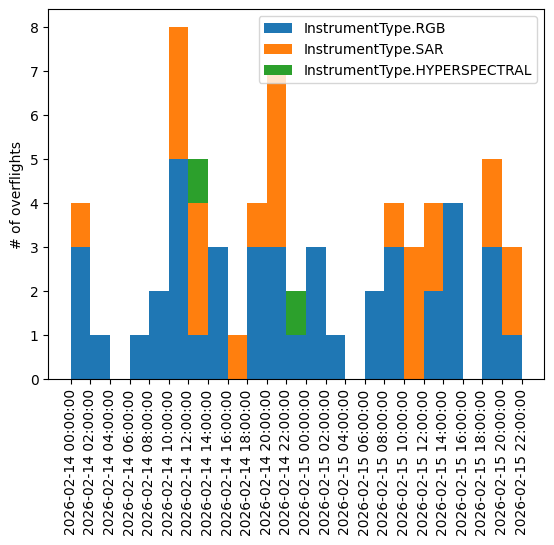

In [25]:
fig, ax = plt.subplots()

bins_dt = [start_time+i*dt.timedelta(seconds=7200) for i in range(24)]
bins = [t.timestamp() for t in bins_dt]

n, bins, patches = ax.hist([
    [o['highest_time'].timestamp() for o in opportunities_list if o['instrument']==instrument.name]
    for instrument in instrument_types
],
    bins=bins,
    histtype='barstacked',
    label = instrument_types,
    )

ax.set_xticks(bins)
ax.set_xticklabels([dt.datetime.fromtimestamp(b) for b in bins], rotation=90)
ax.set_ylabel("# of overflights")
ax.legend()

plt.savefig("overflights_histogram.pdf", bbox_inches='tight')
plt.savefig("overflights_histogram.png", bbox_inches='tight')

## On the spatial distribution of overflight opportunities

### Build a tiling around the area of interest

In [26]:
rotterdam_area = h3.LatLngPoly(
    [
        (Rotterdam.lon_deg-4, Rotterdam.lat_deg-4),
        (Rotterdam.lon_deg-4, Rotterdam.lat_deg+4),
        (Rotterdam.lon_deg+4, Rotterdam.lat_deg+4),
        (Rotterdam.lon_deg+4, Rotterdam.lat_deg-4),
     ]
    )
h3_res = 4
all_h3cells = h3.h3shape_to_cells(rotterdam_area, h3_res)
wet_h3cells = []
for _cell in all_h3cells:
    _cell_lon_deg, _cell_lat_deg = h3.cell_to_latlng(_cell)
    if not is_land(_cell_lon_deg, _cell_lat_deg):
        wet_h3cells.append(_cell)

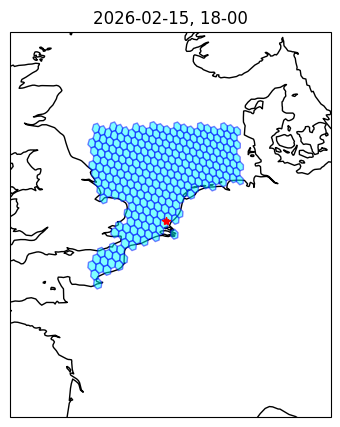

In [27]:

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

_plot_offset_deg = 8

# fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

for (ground_station, satpass) in sat_passes_with_gs:
    axglobal.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    
for _cell in wet_h3cells:
    _boundary = h3.cell_to_boundary(_cell)
    _poly = Polygon(_boundary)
    # print(_poly)
    axglobal.add_geometries([_poly], crs=ccrs.PlateCarree(), edgecolor='blue', facecolor='cyan', alpha=0.5)

axglobal.set_title("{}-{}".format(min_time.strftime("%Y-%m-%d, %H"), (min_time+duration).strftime("%H")))
# plt.show()
axglobal.set_extent((float(ground_station.lon_deg)-_plot_offset_deg, float(ground_station.lon_deg)+_plot_offset_deg, float(ground_station.lat_deg)-_plot_offset_deg, float(ground_station.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())


### For each tile, create a request

In [28]:
duration_h = 6

overflights = {dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0, tzinfo=dt.timezone.utc): {} for start_day in range(14,16) for start_hour in range(0,24,duration_h)}

for start_day in range(14,16):
    for start_hour in range(0,24,duration_h):
        min_time = dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0, tzinfo=dt.timezone.utc)
        duration = dt.timedelta(seconds=3600*duration_h)
        
        for _cell in wet_h3cells:
            
            _cell_lon_deg, _cell_lat_deg = h3.cell_to_latlng(_cell)
            _obs_requests = [
                ObservationRequest(_cell_lon_deg, _cell_lat_deg, min_time=min_time, max_time=min_time+duration, alt_km=0, request_name=_cell, min_elevation_deg=45, instrument=instrument)
                for instrument in instrument_types
            ]
            _opportunities = find_observation_opportunities(_obs_requests, all_satellites)
            overflights[min_time][_cell] = _opportunities

overflights_count = {}
for _start_time in overflights.keys():
    overflights_count[_start_time] = {}
    for _cell in overflights[_start_time].keys():
        overflights_count[_start_time][_cell] = {}
        overflights_count[_start_time][_cell]['total'] = 0
        for _request in overflights[_start_time][_cell].keys():
            _num_overflights = len(overflights[_start_time][_cell][_request])
            overflights_count[_start_time][_cell][_request.instrument] = _num_overflights
            overflights_count[_start_time][_cell]['total'] += _num_overflights

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:30: UserWarning:

no explicit representation of timezones available for np.datetime64

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning:

no explicit representation of timezones available for np.datetime64



#### How many overflights per tile do we get in a 6h window?

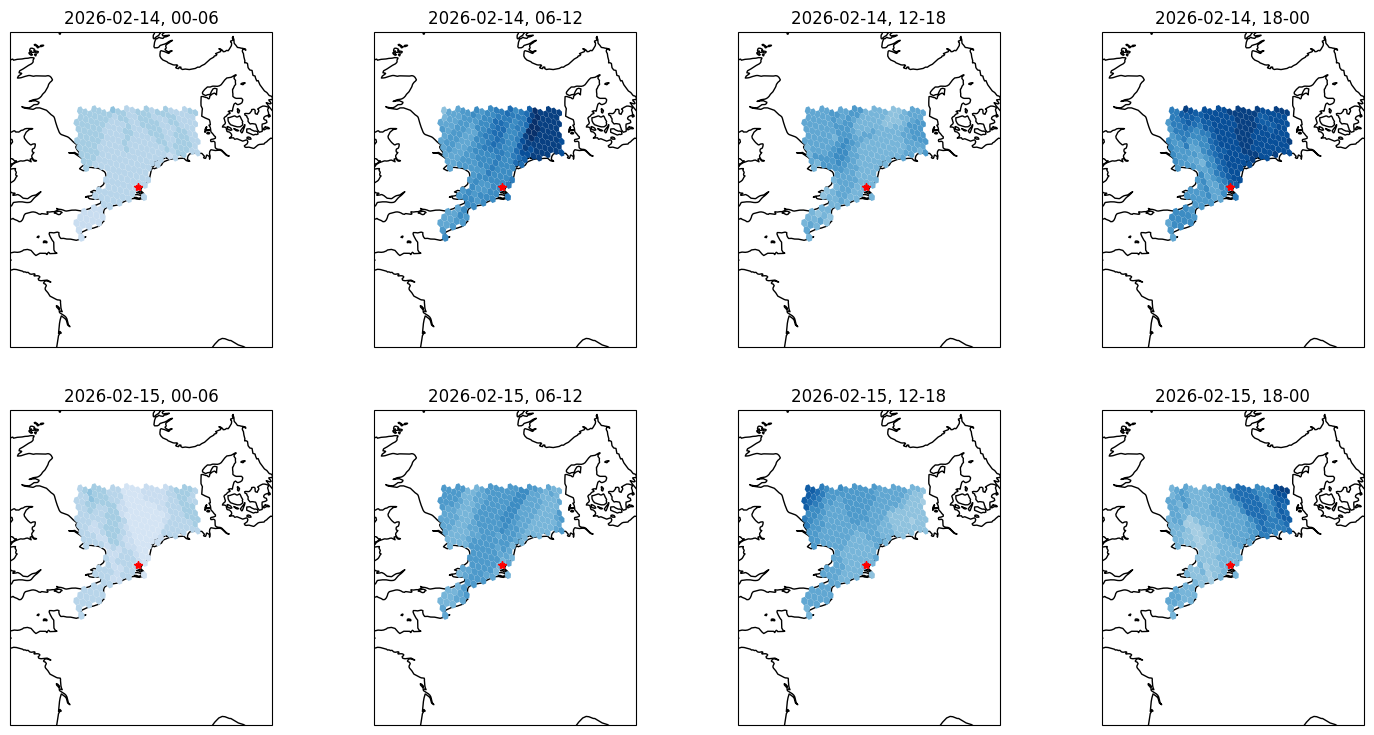

In [29]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

max_num_overflights = max([stats['total'] for _dt in overflights_count.keys() for stats in overflights_count[_dt].values()])

figglobal = plt.figure(figsize=(18,9))

plt_index = 0

# axgloballgd = figglobal.add_subplot(2,4,8)
# # axgloballgd.set_axis_off()
# divider = make_axes_locatable(axgloballgd)
# cax = divider.append_axes('right', size='5%', pad=0.05)
# # fig.colorbar(im1, cax=cax, orientation='vertical')

# figglobal.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, max_num_overflights), cmap='Blues'),
#             ax=cax, orientation='vertical', label='# of overflights')

for start_time in overflights_count.keys():
    cmap = mpl.colormaps["Blues"]
    # figglobal = plt.figure(figsize=(10,5))
    plt_index+=1
    # axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
    axglobal = figglobal.add_subplot(2,4,plt_index, projection=ccrs.Robinson(), )

    # axglobal.set_global()
    axglobal.coastlines()

    _plot_offset_deg = 8

    axglobal.plot(float(Rotterdam.lon_deg), float(Rotterdam.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    for _cell in wet_h3cells:
        _boundary = h3.cell_to_boundary(_cell)
        _poly = Polygon(_boundary)
        # print(_poly)
        num_overflights = overflights_count[start_time][_cell]['total']
        axglobal.add_geometries([_poly], crs=ccrs.PlateCarree(), edgecolor='none', facecolor=cmap(num_overflights/max_num_overflights))

    axglobal.set_title("{}-{}".format(start_time.strftime("%Y-%m-%d, %H"), (start_time+duration).strftime("%H")))
    # plt.show()
    axglobal.set_extent((float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Rotterdam.lat_deg)-_plot_offset_deg, float(Rotterdam.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())


plt.savefig("overflights_6h_intervals.pdf", bbox_inches='tight')
plt.savefig("overflights_6h_intervals.png", bbox_inches='tight')

### How about a 1h window?

In [30]:
duration_h = 1

overflights = {dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0, tzinfo=dt.timezone.utc): {} for start_day in range(14,16) for start_hour in range(0,24,duration_h)}

for start_day in range(14,16):
    for start_hour in range(0,24,duration_h):
        min_time = dt.datetime(2026, 2, start_day, start_hour, 0, 0, 0, tzinfo=dt.timezone.utc)
        duration = dt.timedelta(seconds=3600*duration_h)
        
        for _cell in wet_h3cells:
            
            _cell_lon_deg, _cell_lat_deg = h3.cell_to_latlng(_cell)
            _obs_requests = [
                ObservationRequest(_cell_lon_deg, _cell_lat_deg, min_time=min_time, max_time=min_time+duration, alt_km=0, request_name=_cell, min_elevation_deg=45, instrument=instrument)
                for instrument in instrument_types
            ]
            _opportunities = find_observation_opportunities(_obs_requests, all_satellites)
            overflights[min_time][_cell] = _opportunities

overflights_count = {}
for _start_time in overflights.keys():
    overflights_count[_start_time] = {}
    for _cell in overflights[_start_time].keys():
        overflights_count[_start_time][_cell] = {}
        overflights_count[_start_time][_cell]['total'] = 0
        for _request in overflights[_start_time][_cell].keys():
            _num_overflights = len(overflights[_start_time][_cell][_request])
            overflights_count[_start_time][_cell][_request.instrument] = _num_overflights
            overflights_count[_start_time][_cell]['total'] += _num_overflights

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:30: UserWarning:

no explicit representation of timezones available for np.datetime64

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning:

no explicit representation of timezones available for np.datetime64



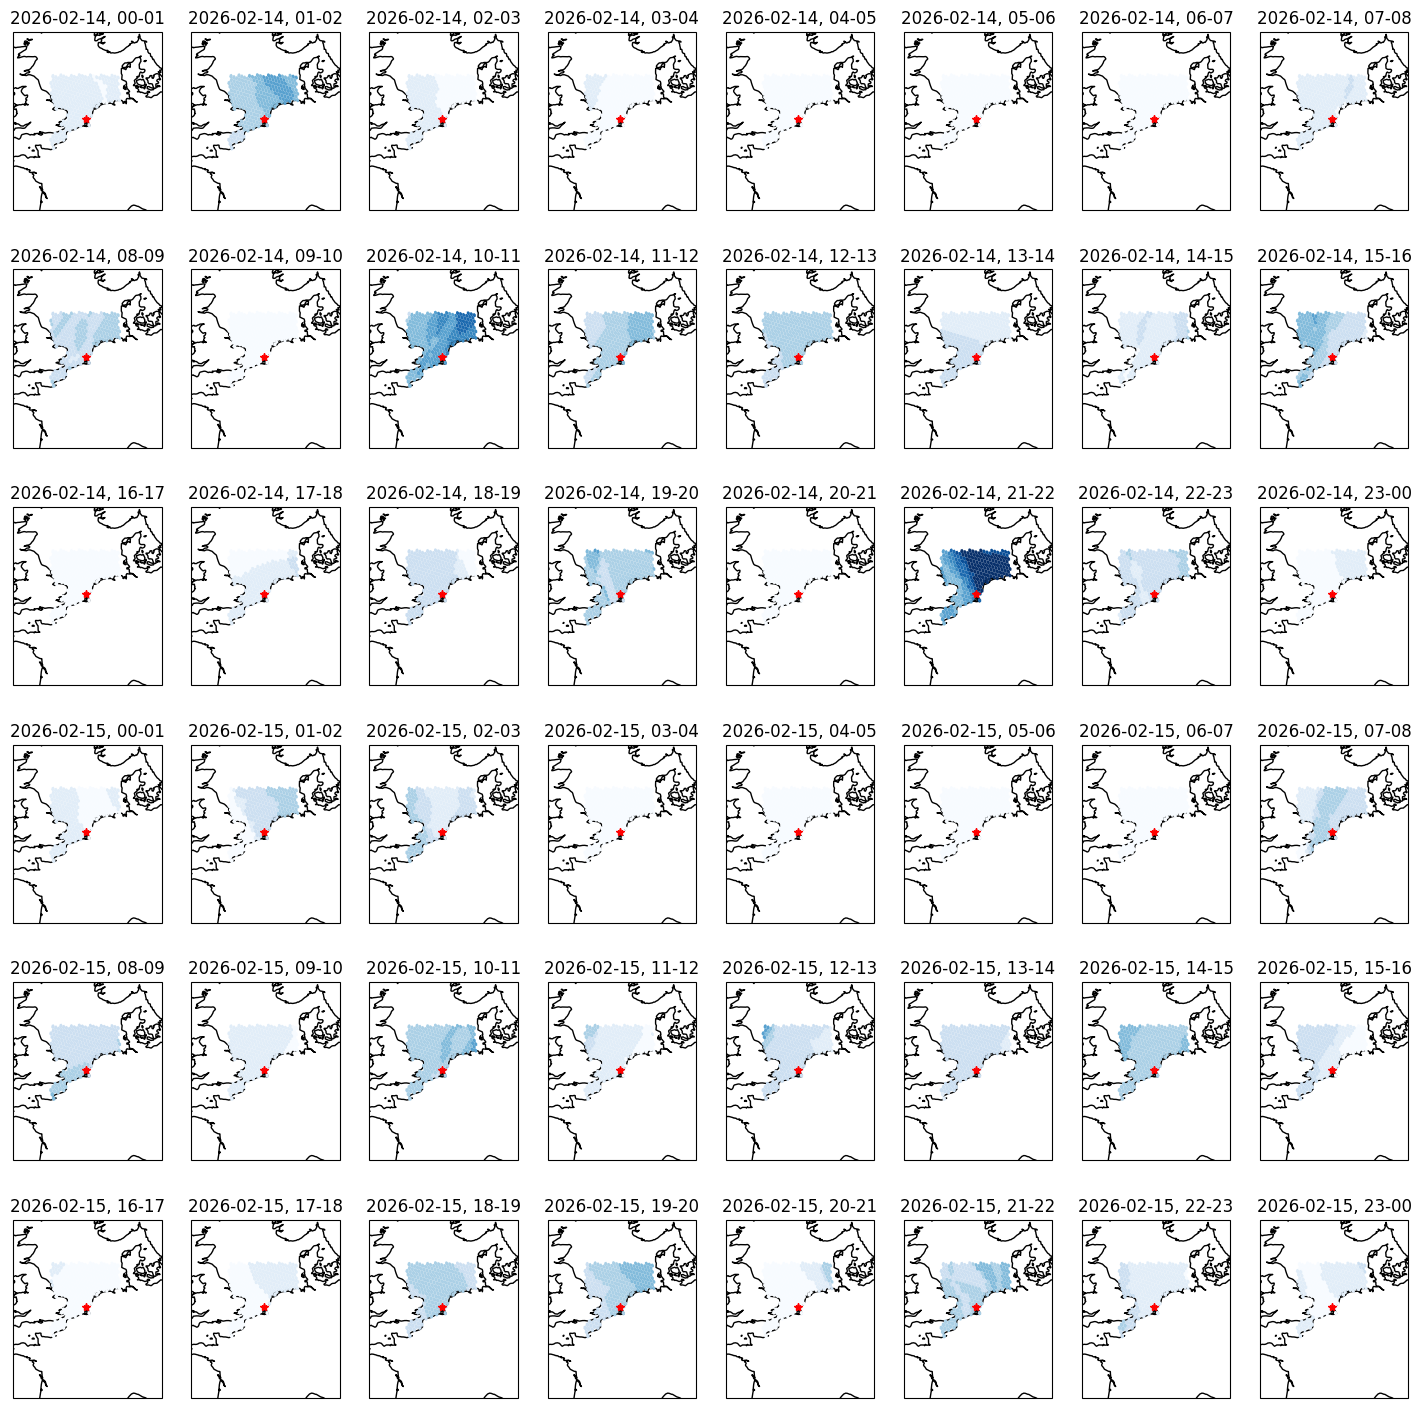

In [31]:
max_num_overflights = max([stats['total'] for _dt in overflights_count.keys() for stats in overflights_count[_dt].values()])

figglobal = plt.figure(figsize=(18,18))
# axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())

plt_index = 0
for start_time in overflights_count.keys():
    cmap = mpl.colormaps["Blues"]
    # figglobal = plt.figure(figsize=(10,5))
    plt_index+=1
    axglobal = figglobal.add_subplot(6,8,plt_index, projection=ccrs.Robinson())
    
    # axglobal.set_global()
    axglobal.coastlines()

    _plot_offset_deg = 8

    axglobal.plot(float(Rotterdam.lon_deg), float(Rotterdam.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    for _cell in wet_h3cells:
        _boundary = h3.cell_to_boundary(_cell)
        _poly = Polygon(_boundary)
        # print(_poly)
        num_overflights = overflights_count[start_time][_cell]['total']
        axglobal.add_geometries([_poly], crs=ccrs.PlateCarree(), edgecolor='none', facecolor=cmap(num_overflights/max_num_overflights))

    axglobal.set_title("{}-{}".format(start_time.strftime("%Y-%m-%d, %H"), (start_time+duration).strftime("%H")))
    # plt.show()
    axglobal.set_extent((float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Rotterdam.lat_deg)-_plot_offset_deg, float(Rotterdam.lat_deg)+_plot_offset_deg), crs=ccrs.PlateCarree())

# figglobal.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, max_num_overflights), cmap='Blues'),
#             ax=axglobal, orientation='vertical', label='# of overflights')

plt.savefig("overflights_1h_intervals.pdf", bbox_inches='tight')
plt.savefig("overflights_1h_intervals.png", bbox_inches='tight')